# Appendix: Generators and Relations

**Source orientation:** Armstrong, *Basic Topology*, Appendix, printed pp. 241-243; PDF reader pp. 248-250.

## Chapter Goal

Use free groups as the scratch space for loops, use relations as instructions for which loop words become trivial, and read a group presentation as a quotient by all conjugates of the stated relations. The point for topology is practical: edge groups, van Kampen calculations, and knot groups all turn geometric loops into algebraic words.

## Computational Translation Guide

| Book idea | Computational model in this notebook | What to inspect |
| --- | --- | --- |
| Free group on generators | signed letters such as `a`, `B`, where capital means inverse | a word has a unique reduced normal form |
| Reduced word | a stack process that cancels adjacent inverse pairs | applying reduction twice changes nothing |
| Presentation `<X | R>` | start with the free group `F(X)`, then force every word in `R` to act like the identity | relation words close loops in a Cayley graph |
| Normal closure of relations | relation loops must close after every change of basepoint | conjugate relation loops appear at every vertex |
| Free product | alternating normal forms from two factor groups | only adjacent letters from the same factor simplify |

The source pages are used only to orient the topics and notation. The prose, examples, diagrams, and checks below are original teaching material for this notebook.

## Standalone Reading Guide

This appendix supplies the algebraic language used when topology turns loops into groups. A presentation separates a group into two pieces of information: generators, which name the basic moves, and relations, which say which closed words should be treated as doing nothing. The point is not to list every element directly. Instead, the notebook shows how to compute with words, reduce obvious inverse pairs, impose extra relations, and visualize the quotient that results.

The examples are intentionally small because presentations are easiest to misunderstand when the graph becomes too large. A free word reduction stack shows what is true before any relation is imposed: only adjacent inverse letters cancel. The presentation and Cayley-graph sections then add relations and make the quotient visible as a network of states. Normal closure appears because a relation in a group presentation is not killed only at one chosen starting point; every conjugate of that relation must vanish as well. The Schreier-style diagram changes viewpoint from elements to orbits or cosets, which is the same move that later appears in covering-space calculations.

Use the final topology-oriented lab as a translation exercise. When a cell complex or knot diagram produces a presentation, the generators usually come from chosen loops or arcs, while the relations come from attaching maps, faces, or crossings. The computational checks in this appendix ask whether the stated relations evaluate to the identity, whether graph moves are consistent, and whether normal forms remain stable after reduction. Those are the algebraic habits needed before applying presentations to fundamental groups.


In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display


def find_book_root() -> Path:
    starts = [Path.cwd(), Path.cwd() / "Basic-Topology"]
    for start in starts:
        if not start.exists():
            continue
        for candidate in [start, *start.parents]:
            if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
                return candidate.resolve()
    raise RuntimeError("Run from the workspace root or Basic-Topology root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_dir, artifact_path, assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html

UNIT = "appendix-generators-and-relations"
artifact_dir(UNIT, "figures")
artifact_dir(UNIT, "html")
artifact_dir(UNIT, "checks")
artifact_dir(UNIT, "tables")

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 10})


def book_rel(path: str | Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


artifact_manifest: list[Path] = []
check_manifest: list[Path] = []
print(f"Book root: {BOOK_ROOT}")

Book root: D:\Geometry\Basic-Topology


## 1. Free Words As A Reduction Machine

A free group is the group where no accidental equation exists between generators. The only simplification allowed in a raw word is cancellation of a letter with its inverse. In the code below, lower-case letters are generators and upper-case letters are their inverses, so `bB` and `Bb` disappear.

**Visual choice.** A stack trace is the right model because reduction is local: the next letter only checks the top of the current reduced word. Inspect where the stack length drops; those are the exact points where the free group has used an inverse law and nothing else.

,step,read,before,action,after,length
0,0,,e,start,e,0
1,1,a,e,append,a,1
2,2,b,a,append,ab,2
3,3,B,ab,cancel bB,a,1
4,4,A,a,cancel aA,e,0
5,5,c,e,append,c,1
6,6,C,c,cancel cC,e,0
7,7,a,e,append,a,1
8,8,a,a,append,aa,2
9,9,B,aa,append,aaB,3


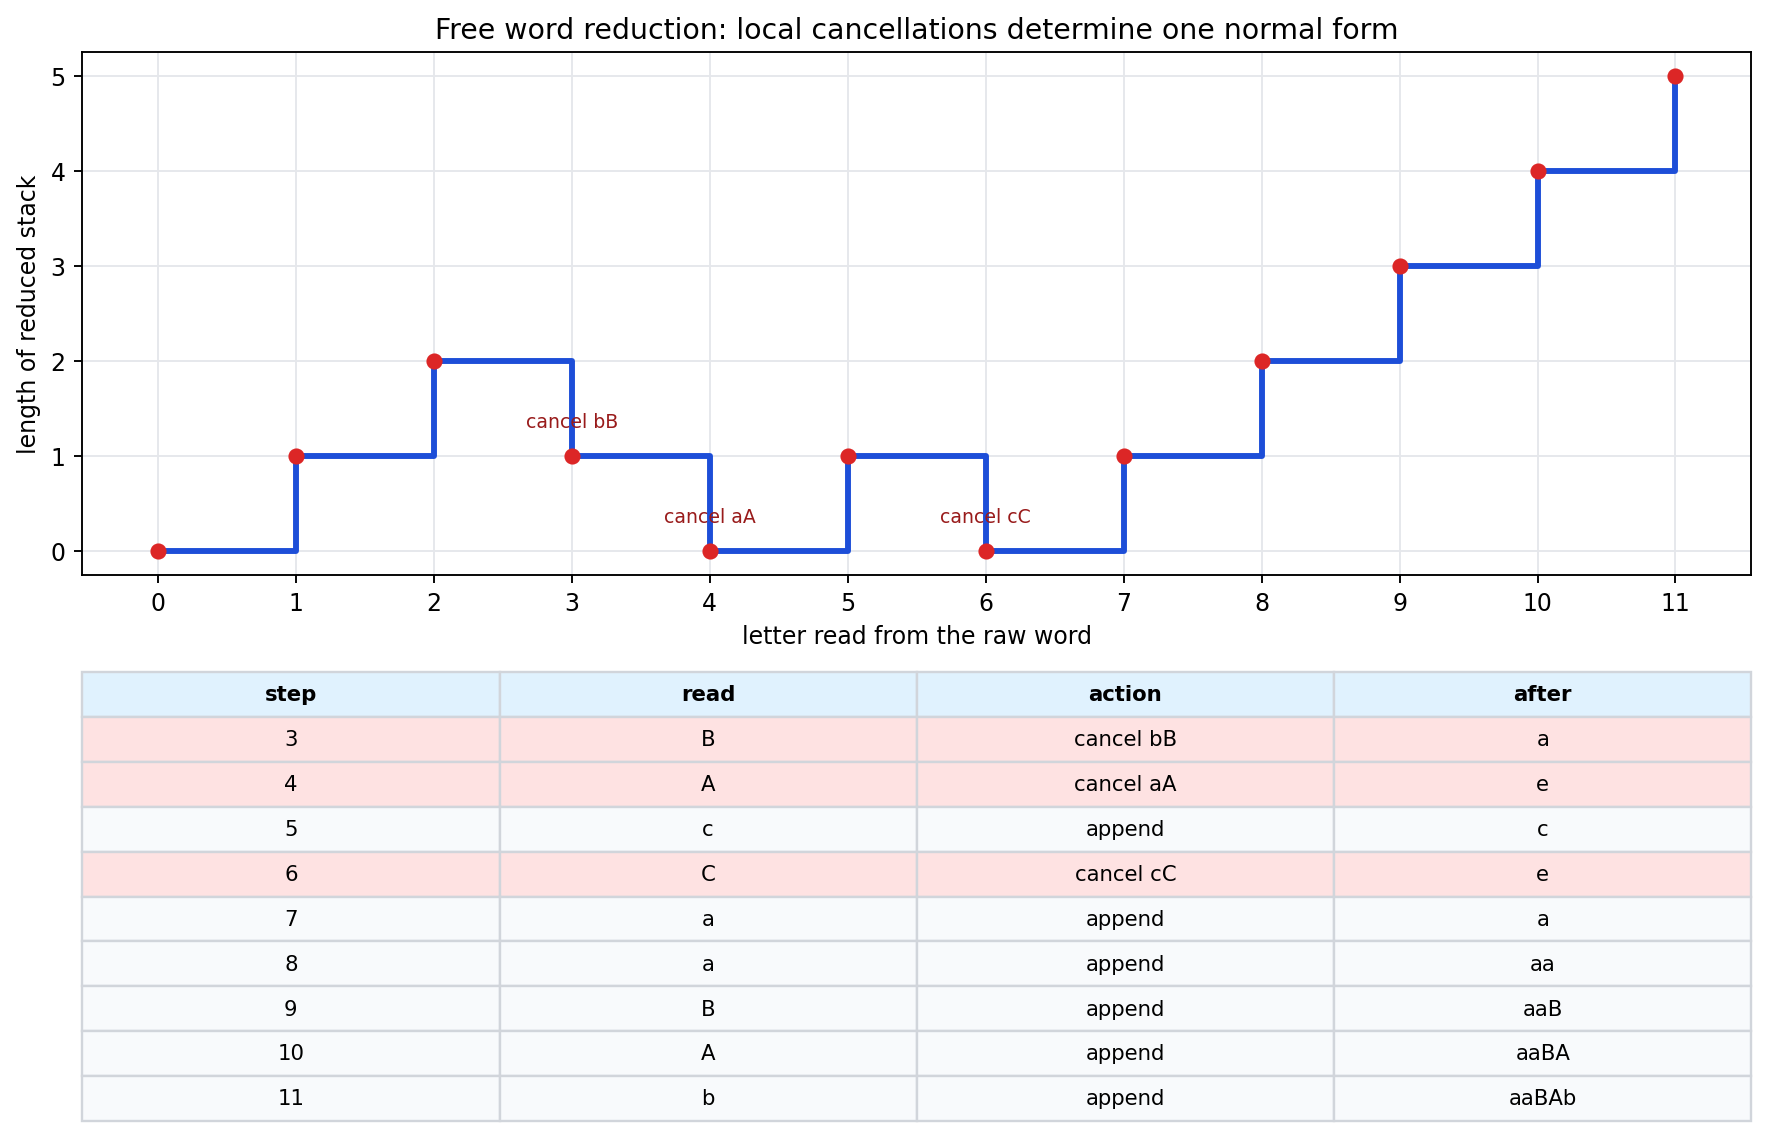

{'concept': 'free word reduction',
 'raw_word': 'abBAcCaaBAb',
 'reduced_word': 'aaBAb',
 'compressed_blocks': 'a^2 b^-1 a^-1 b',
 'reduction_idempotent': True,
 'inverse_product_reduces_to_identity': True,
 'trace_final_matches_reduction': True,
 'cancellation_steps': 3}

In [2]:
def clean_word(word: str | list[str] | tuple[str, ...]) -> list[str]:
    if isinstance(word, str):
        return [ch for ch in word.replace(" ", "") if ch != "1"]
    return list(word)


def inverse_letter(ch: str) -> str:
    return ch.swapcase()


def reduce_word(word: str | list[str] | tuple[str, ...]) -> str:
    stack: list[str] = []
    for ch in clean_word(word):
        if stack and stack[-1] == inverse_letter(ch):
            stack.pop()
        else:
            stack.append(ch)
    return "".join(stack)


def inverse_word(word: str | list[str] | tuple[str, ...]) -> str:
    return "".join(inverse_letter(ch) for ch in reversed(clean_word(word)))


def multiply_words(*words: str) -> str:
    return reduce_word("".join(words))


def exponent_blocks(reduced_word: str) -> list[tuple[str, int]]:
    blocks: list[tuple[str, int]] = []
    for ch in clean_word(reduced_word):
        gen = ch.lower()
        exp = 1 if ch.islower() else -1
        if blocks and blocks[-1][0] == gen:
            new_exp = blocks[-1][1] + exp
            if new_exp == 0:
                blocks.pop()
            else:
                blocks[-1] = (gen, new_exp)
        else:
            blocks.append((gen, exp))
    return blocks


def format_blocks(word: str) -> str:
    blocks = exponent_blocks(reduce_word(word))
    if not blocks:
        return "e"
    return " ".join(gen if exp == 1 else f"{gen}^{exp}" for gen, exp in blocks)


def reduction_trace(word: str) -> pd.DataFrame:
    rows = [{"step": 0, "read": "", "before": "e", "action": "start", "after": "e", "length": 0}]
    stack: list[str] = []
    for step, ch in enumerate(clean_word(word), start=1):
        before = "".join(stack) or "e"
        if stack and stack[-1] == inverse_letter(ch):
            pair = stack[-1] + ch
            stack.pop()
            action = f"cancel {pair}"
        else:
            stack.append(ch)
            action = "append"
        rows.append({"step": step, "read": ch, "before": before, "action": action, "after": "".join(stack) or "e", "length": len(stack)})
    return pd.DataFrame(rows)


sample_word = "abBAcCaaBAb"
trace_df = reduction_trace(sample_word)
reduced_sample = reduce_word(sample_word)
trace_csv = artifact_path(UNIT, "tables", "free-word-reduction-trace.csv")
trace_df.to_csv(trace_csv, index=False)
artifact_manifest.append(trace_csv)

fig, (ax_len, ax_table) = plt.subplots(2, 1, figsize=(10.5, 6.8), gridspec_kw={"height_ratios": [2.2, 1.8]})
ax_len.step(trace_df["step"], trace_df["length"], where="post", color="#1d4ed8", linewidth=2.5)
ax_len.scatter(trace_df["step"], trace_df["length"], color="#dc2626", s=34, zorder=3)
for _, row in trace_df.iloc[1:].iterrows():
    if row["action"].startswith("cancel"):
        ax_len.annotate(row["action"], xy=(row["step"], row["length"]), xytext=(0, 12), textcoords="offset points", ha="center", fontsize=8, color="#991b1b")
ax_len.set_title("Free word reduction: local cancellations determine one normal form")
ax_len.set_xlabel("letter read from the raw word")
ax_len.set_ylabel("length of reduced stack")
ax_len.set_xticks(trace_df["step"])
ax_len.grid(True, color="#e5e7eb")

ax_table.axis("off")
visible = trace_df[["step", "read", "action", "after"]].tail(9)
table = ax_table.table(cellText=visible.values, colLabels=visible.columns, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.35)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#d1d5db")
    if row == 0:
        cell.set_facecolor("#e0f2fe")
        cell.set_text_props(weight="bold")
    elif "cancel" in str(visible.iloc[row - 1]["action"]):
        cell.set_facecolor("#fee2e2")
    else:
        cell.set_facecolor("#f8fafc")
fig.tight_layout()
reduction_png = save_matplotlib(fig, UNIT, "figures", "free-word-reduction-stack.png", dpi=170)
plt.close(fig)
artifact_manifest.append(reduction_png)

free_word_checks = {
    "concept": "free word reduction",
    "raw_word": sample_word,
    "reduced_word": reduced_sample or "e",
    "compressed_blocks": format_blocks(reduced_sample),
    "reduction_idempotent": reduce_word(reduced_sample) == reduced_sample,
    "inverse_product_reduces_to_identity": multiply_words(sample_word, inverse_word(sample_word)) == "",
    "trace_final_matches_reduction": trace_df.iloc[-1]["after"] == (reduced_sample or "e"),
    "cancellation_steps": int(trace_df["action"].str.startswith("cancel").sum()),
}
free_word_check_path = save_json(free_word_checks, UNIT, "checks", "free-word-reduction-checks.json")
check_manifest.append(free_word_check_path)

display(trace_df)
display_artifact(reduction_png, width=900)
free_word_checks

## 2. Presentations: Relations Turn A Free Group Into A Quotient

A presentation starts with a free group and then declares selected words to be trivial. For a concrete finite model, use the dihedral presentation `D_10 = <x, y | x^5, y^2, (xy)^2>`.

Here `x` is rotation of a pentagon and `y` is a reflection. The free group on `x,y` still contains every raw word; the quotient remembers only the ten normal forms `x^i` and `x^i y` after the three relations are imposed.

**Visual choice.** A Cayley graph is an inspectable multiplication table. Every vertex has one outgoing `x` edge and one outgoing `y` edge, and every stated relation closes a loop from every starting vertex.

,raw_word,quotient_normal_form,state_label,same_action_after_rewrite,rewrite_idempotent
0,xyxxy,xxxx,x^4,True,True
1,yyxxxxy,xxxxy,x^4y,True,True
2,xyxyx,x,x,True,True
3,yxyx,e,e,True,True
4,xxxxyxy,xxx,x^3,True,True
5,Xyxyx,xxxx,x^4,True,True


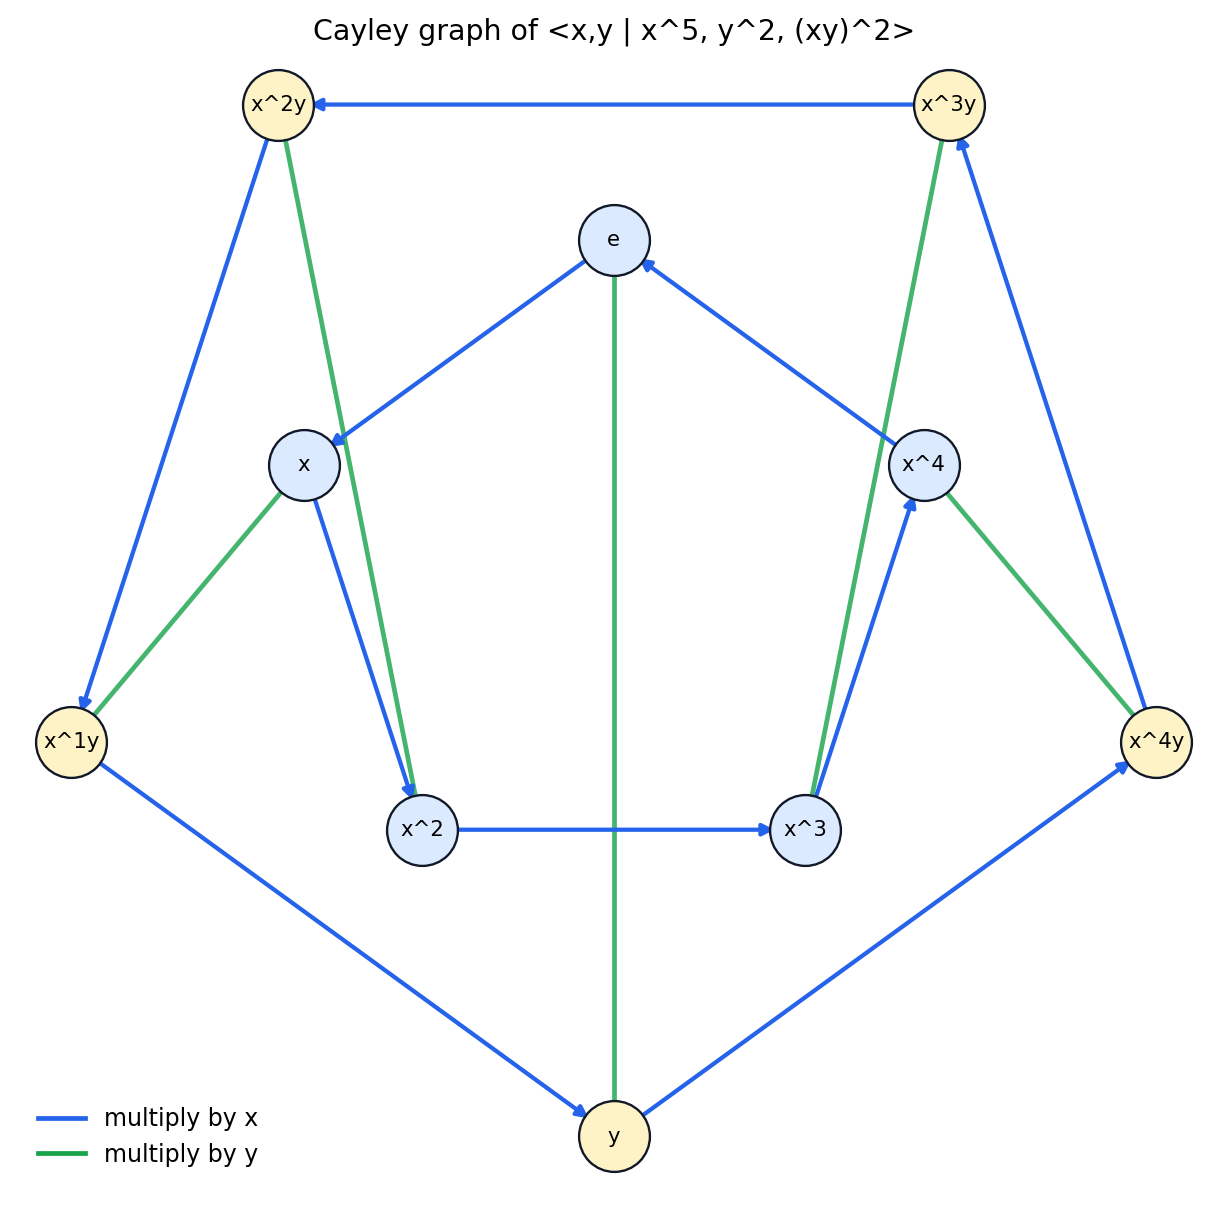

{'concept': 'presentation relation rewriting',
 'presentation': '<x,y | x^5, y^2, (xy)^2>',
 'relation_words_evaluate_to_identity': {'x^5': True,
  'y^2': True,
  '(xy)^2': True},
 'all_relation_words_identity': True,
 'rewrite_examples_preserve_action': True,
 'rewrite_idempotent_on_examples': True,
 'normal_forms_count': 10}

In [3]:
N = 5
D_ID = (0, 0)


def d_mul(a: tuple[int, int], b: tuple[int, int], n: int = N) -> tuple[int, int]:
    i, j = a
    k, ell = b
    return ((i + (k if j == 0 else -k)) % n, (j + ell) % 2)


def d_generator(ch: str, n: int = N) -> tuple[int, int]:
    if ch == "x":
        return (1, 0)
    if ch == "X":
        return (n - 1, 0)
    if ch in {"y", "Y"}:
        return (0, 1)
    raise ValueError(ch)


def d_eval(word: str, start: tuple[int, int] = D_ID, n: int = N) -> tuple[int, int]:
    state = start
    for ch in clean_word(word):
        state = d_mul(state, d_generator(ch, n), n)
    return state


def d_label(state: tuple[int, int]) -> str:
    i, j = state
    rot = "e" if i == 0 else ("x" if i == 1 else f"x^{i}")
    if j == 0:
        return rot
    return "y" if i == 0 else f"x^{i}y"


def d_state_to_word(state: tuple[int, int]) -> str:
    i, j = state
    return "x" * i + ("y" if j else "")


def d_normal_form(word: str) -> str:
    return d_state_to_word(d_eval(word)) or "e"


relation_words = {"x^5": "xxxxx", "y^2": "yy", "(xy)^2": "xyxy"}
relation_results = {name: d_eval(word) == D_ID for name, word in relation_words.items()}

rewrite_examples = ["xyxxy", "yyxxxxy", "xyxyx", "yxyx", "xxxxyxy", "Xyxyx"]
rewrite_rows = []
for word in rewrite_examples:
    normal = d_normal_form(word)
    normal_word = "" if normal == "e" else normal
    rewrite_rows.append({
        "raw_word": word,
        "quotient_normal_form": normal,
        "state_label": d_label(d_eval(word)),
        "same_action_after_rewrite": d_eval(word) == d_eval(normal_word),
        "rewrite_idempotent": d_normal_form(normal_word) == normal,
    })
rewrite_df = pd.DataFrame(rewrite_rows)
rewrite_csv = artifact_path(UNIT, "tables", "dihedral-relation-rewriting-table.csv")
rewrite_df.to_csv(rewrite_csv, index=False)
artifact_manifest.append(rewrite_csv)

G = nx.MultiDiGraph()
elements = [(i, j) for j in (0, 1) for i in range(N)]
for state in elements:
    G.add_node(state, label=d_label(state), layer=state[1])
for state in elements:
    for gen in ("x", "y"):
        G.add_edge(state, d_eval(gen, start=state), generator=gen)

pos = {}
for i in range(N):
    angle = 2 * math.pi * i / N + math.pi / 2
    pos[(i, 0)] = np.array([math.cos(angle), math.sin(angle)])
    pos[(i, 1)] = np.array([1.75 * math.cos(-angle), 1.75 * math.sin(-angle)])

fig, ax = plt.subplots(figsize=(8.2, 7.2))
for i in range(N):
    u, v = (i, 0), (i, 1)
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color="#16a34a", linewidth=2.0, alpha=0.8, zorder=1)
for state in elements:
    target = d_eval("x", start=state)
    ax.annotate("", xy=pos[target], xytext=pos[state], arrowprops=dict(arrowstyle="-|>", color="#2563eb", lw=1.8, shrinkA=13, shrinkB=13), zorder=2)
for layer, color in [(0, "#dbeafe"), (1, "#fef3c7")]:
    nodes = [state for state in elements if state[1] == layer]
    ax.scatter([pos[s][0] for s in nodes], [pos[s][1] for s in nodes], s=900, color=color, edgecolor="#111827", zorder=3)
for state in elements:
    ax.text(pos[state][0], pos[state][1], d_label(state), ha="center", va="center", fontsize=9, zorder=4)
ax.plot([], [], color="#2563eb", linewidth=2, label="multiply by x")
ax.plot([], [], color="#16a34a", linewidth=2, label="multiply by y")
ax.set_title("Cayley graph of <x,y | x^5, y^2, (xy)^2>")
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
cayley_png = save_matplotlib(fig, UNIT, "figures", "presentation-quotient-cayley-graph.png", dpi=170)
plt.close(fig)
artifact_manifest.append(cayley_png)

edge_traces = []
for gen, color in [("x", "#2563eb"), ("y", "#16a34a")]:
    xs, ys = [], []
    for u, v, data in G.edges(data=True):
        if data["generator"] != gen or (gen == "y" and u[1] == 1):
            continue
        xs += [pos[u][0], pos[v][0], None]
        ys += [pos[u][1], pos[v][1], None]
    edge_traces.append(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color=color, width=3), name=f"{gen}-edges", hoverinfo="skip"))
node_trace = go.Scatter(
    x=[pos[s][0] for s in elements],
    y=[pos[s][1] for s in elements],
    mode="markers+text",
    text=[d_label(s) for s in elements],
    textposition="middle center",
    marker=dict(size=42, color=["#dbeafe" if s[1] == 0 else "#fef3c7" for s in elements], line=dict(color="#111827", width=1)),
    hovertext=[f"state {d_label(s)}<br>x -> {d_label(d_eval('x', start=s))}<br>y -> {d_label(d_eval('y', start=s))}" for s in elements],
    hoverinfo="text",
    name="group elements",
)
fig_html = go.Figure(data=[*edge_traces, node_trace])
fig_html.update_layout(title="Interactive Cayley graph for the dihedral presentation", showlegend=True, width=850, height=650, xaxis=dict(visible=False, scaleanchor="y", scaleratio=1), yaxis=dict(visible=False), margin=dict(l=20, r=20, t=60, b=20), plot_bgcolor="white")
cayley_html = save_plotly_html(fig_html, UNIT, "html", "dihedral-presentation-cayley-graph.html", include_plotlyjs=True)
artifact_manifest.append(cayley_html)

relation_rewriting_checks = {
    "concept": "presentation relation rewriting",
    "presentation": "<x,y | x^5, y^2, (xy)^2>",
    "relation_words_evaluate_to_identity": relation_results,
    "all_relation_words_identity": all(relation_results.values()),
    "rewrite_examples_preserve_action": bool(rewrite_df["same_action_after_rewrite"].all()),
    "rewrite_idempotent_on_examples": bool(rewrite_df["rewrite_idempotent"].all()),
    "normal_forms_count": len({d_normal_form(d_state_to_word(s)) for s in elements}),
}
relation_check_path = save_json(relation_rewriting_checks, UNIT, "checks", "relation-rewriting-checks.json")
check_manifest.append(relation_check_path)

display(rewrite_df)
display_artifact(cayley_png, width=820)
display_artifact(cayley_html, width="100%", height=520)
relation_rewriting_checks

## 3. Normal Closure: A Relation Must Vanish At Every Basepoint

Killing a relation word `r` only at the identity is not enough for a quotient group. A normal subgroup must also contain every conjugate `g r g^-1`. In a Cayley graph this has a direct visual meaning: after walking to any vertex by `g`, the relation loop `r` closes there too, then `g^-1` returns to the identity.

**Visual choice.** A highlighted conjugate loop shows the algebraic word `g r g^-1`; faint copies show that the same relation loop closes from every group element. This is the graph-level intuition behind quotienting by the normal closure of the relations.

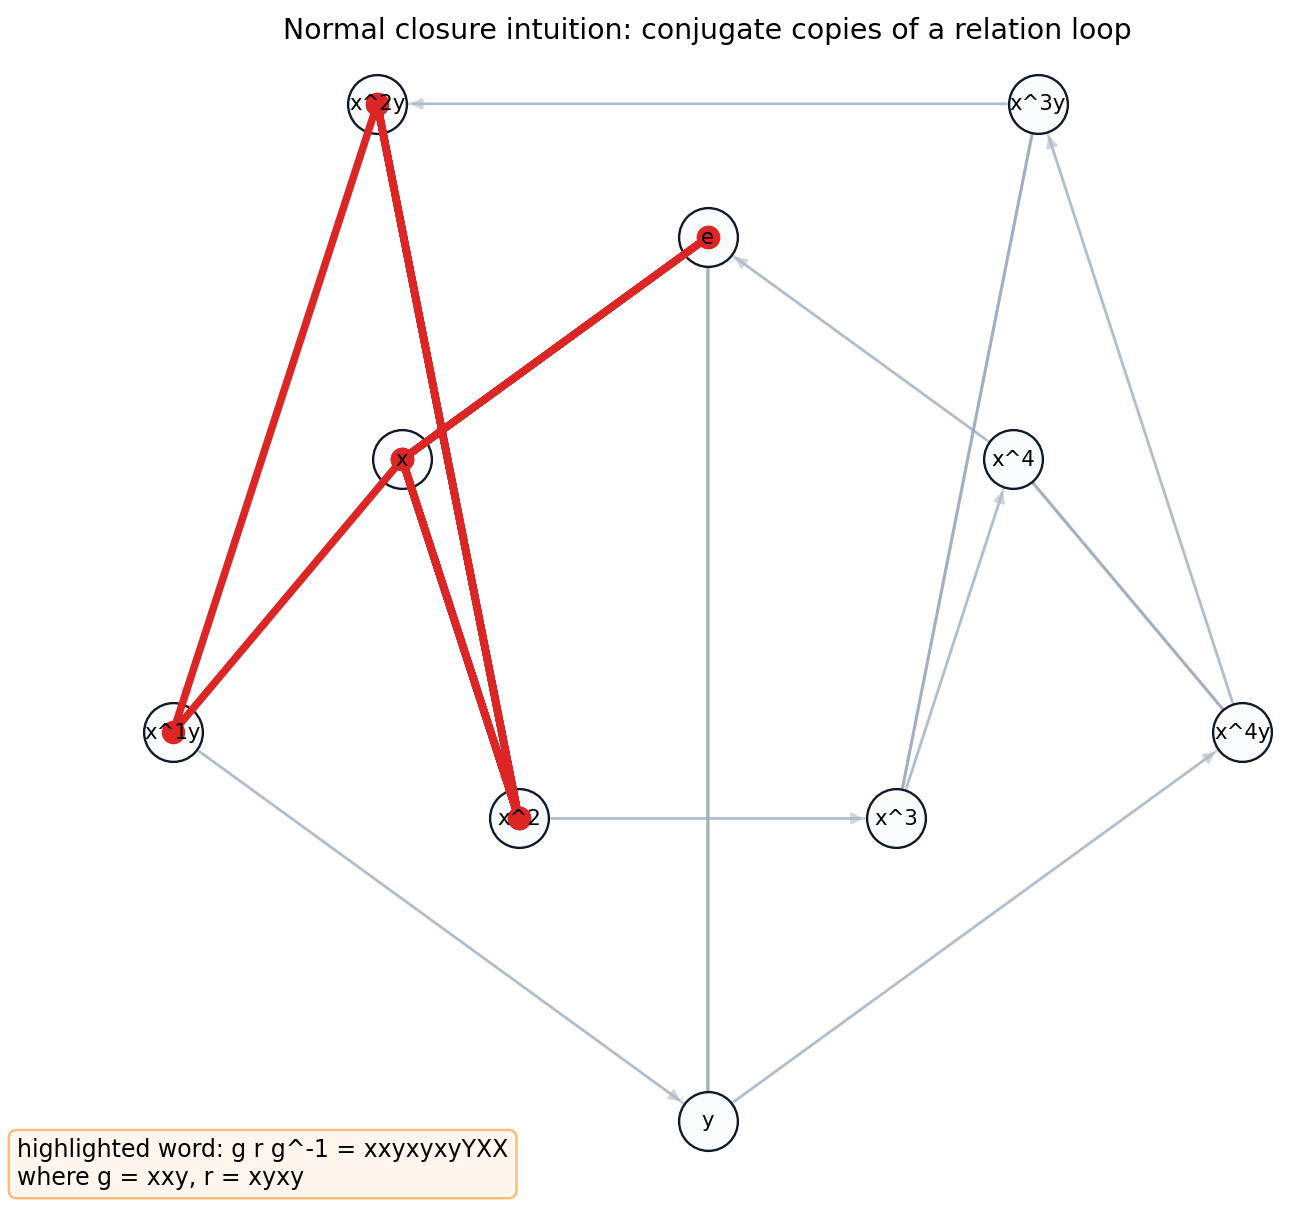

{'concept': 'normal closure of relation words',
 'relation_word': 'xyxy',
 'base_change_word': 'xxy',
 'conjugate_word': 'xxyxyxyYXX',
 'conjugate_evaluates_to_identity': True,
 'relation_loop_closes_at_every_vertex': True,
 'vertices_checked': 10}

In [4]:
def path_for_word(word: str, start: tuple[int, int] = D_ID) -> list[tuple[int, int]]:
    path = [start]
    state = start
    for ch in clean_word(word):
        state = d_eval(ch, start=state)
        path.append(state)
    return path


relation_for_loop = "xyxy"
base_change = "xxy"
conjugate_word = base_change + relation_for_loop + inverse_word(base_change)
conjugate_path = path_for_word(conjugate_word)
all_relation_loop_checks = {d_label(start): path_for_word(relation_for_loop, start=start)[-1] == start for start in elements}

fig, ax = plt.subplots(figsize=(8.2, 7.2))
for state in elements:
    loop = path_for_word(relation_for_loop, start=state)
    coords = np.array([pos[s] for s in loop])
    ax.plot(coords[:, 0], coords[:, 1], color="#94a3b8", linewidth=1.2, alpha=0.28, zorder=1)
for i in range(N):
    u, v = (i, 0), (i, 1)
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color="#d1d5db", linewidth=1.2, zorder=0)
for state in elements:
    target = d_eval("x", start=state)
    ax.annotate("", xy=pos[target], xytext=pos[state], arrowprops=dict(arrowstyle="-|>", color="#d1d5db", lw=1.0, shrinkA=14, shrinkB=14), zorder=0)
coords = np.array([pos[s] for s in conjugate_path])
ax.plot(coords[:, 0], coords[:, 1], color="#dc2626", linewidth=3.2, zorder=3)
ax.scatter(coords[:, 0], coords[:, 1], s=80, color="#dc2626", zorder=4)
for state in elements:
    ax.scatter(pos[state][0], pos[state][1], s=620, color="#f8fafc", edgecolor="#111827", zorder=2)
    ax.text(pos[state][0], pos[state][1], d_label(state), ha="center", va="center", fontsize=9, zorder=5)
ax.text(-2.15, -1.95, f"highlighted word: g r g^-1 = {conjugate_word}\nwhere g = {base_change}, r = {relation_for_loop}", fontsize=10, bbox=dict(boxstyle="round,pad=0.35", facecolor="#fff7ed", edgecolor="#fdba74"))
ax.set_title("Normal closure intuition: conjugate copies of a relation loop")
ax.set_aspect("equal")
ax.axis("off")
fig.tight_layout()
normal_closure_png = save_matplotlib(fig, UNIT, "figures", "normal-closure-conjugate-loops.png", dpi=170)
plt.close(fig)
artifact_manifest.append(normal_closure_png)

normal_closure_checks = {
    "concept": "normal closure of relation words",
    "relation_word": relation_for_loop,
    "base_change_word": base_change,
    "conjugate_word": conjugate_word,
    "conjugate_evaluates_to_identity": d_eval(conjugate_word) == D_ID,
    "relation_loop_closes_at_every_vertex": all(all_relation_loop_checks.values()),
    "vertices_checked": len(all_relation_loop_checks),
}
normal_closure_check_path = save_json(normal_closure_checks, UNIT, "checks", "normal-closure-checks.json")
check_manifest.append(normal_closure_check_path)

display_artifact(normal_closure_png, width=820)
normal_closure_checks

## 4. A Schreier-Style Quotient View

A Cayley graph keeps one vertex per group element. A Schreier-style graph keeps one vertex per coset or orbit point. For the dihedral example, collapse attention to the five vertices of the pentagon on which the group acts: `x` rotates the vertex labels and `y` reflects them.

**Visual choice.** This graph is smaller than the Cayley graph but still tests the same relations as permutations. It models the common topological move of letting a presentation act on a structured set, such as lifts, cosets, or regions in a covering calculation.

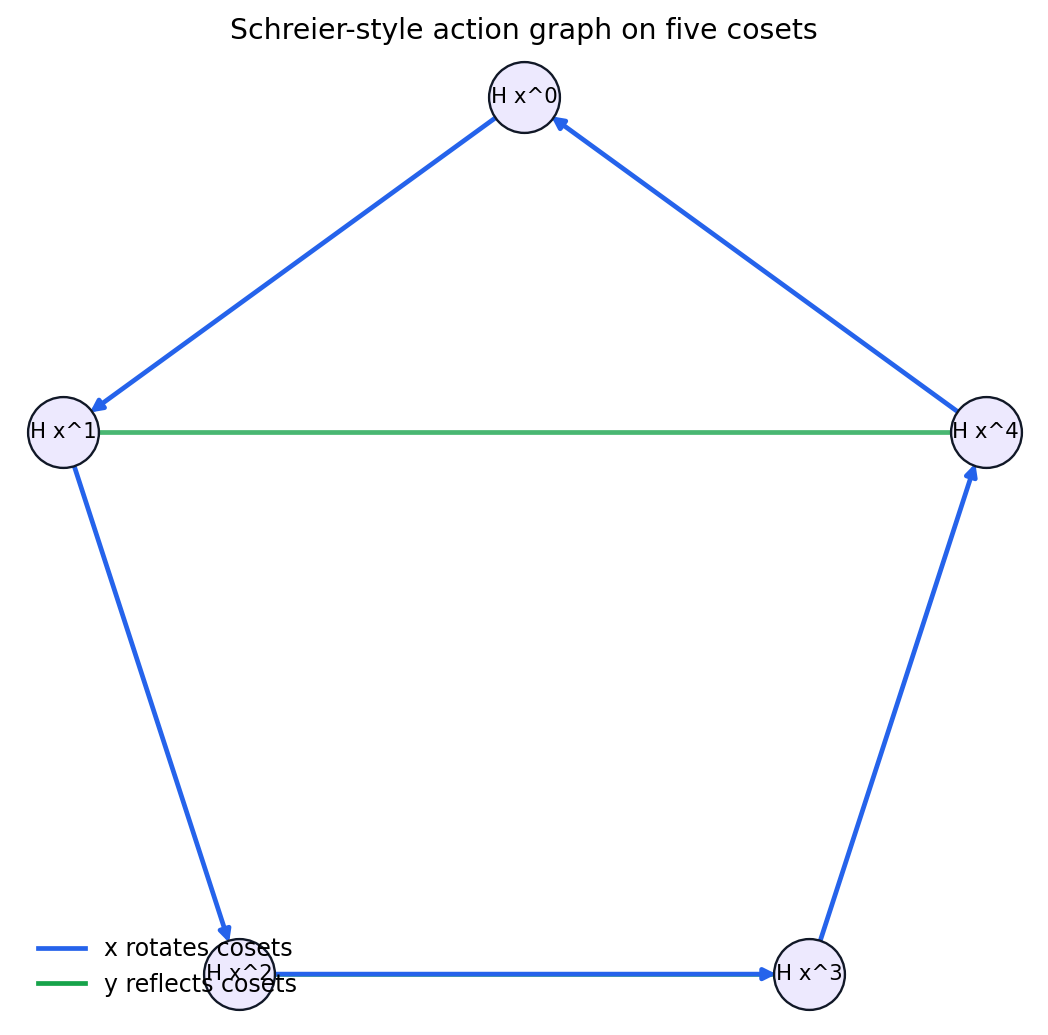

{'concept': 'Schreier-style coset action graph',
 'vertices': 5,
 'x_edges_form_cycle': True,
 'y_is_involution_on_vertices': True,
 'presentation_relations_act_trivially': {'x^5': True,
  'y^2': True,
  '(xy)^2': True},
 'all_presentation_relations_hold': True}

In [5]:
def schreier_x(i: int, n: int = N) -> int:
    return (i + 1) % n


def schreier_y(i: int, n: int = N) -> int:
    return (-i) % n


def apply_schreier_word(word: str, start: int, n: int = N) -> int:
    state = start
    for ch in clean_word(word):
        if ch == "x":
            state = schreier_x(state, n)
        elif ch == "X":
            state = (state - 1) % n
        elif ch in {"y", "Y"}:
            state = schreier_y(state, n)
        else:
            raise ValueError(ch)
    return state


s_pos = {i: np.array([math.cos(2 * math.pi * i / N + math.pi / 2), math.sin(2 * math.pi * i / N + math.pi / 2)]) for i in range(N)}
fig, ax = plt.subplots(figsize=(6.8, 6.2))
for i in range(N):
    j = schreier_x(i)
    ax.annotate("", xy=s_pos[j], xytext=s_pos[i], arrowprops=dict(arrowstyle="-|>", color="#2563eb", lw=2.0, shrinkA=14, shrinkB=14), zorder=2)
for i in range(N):
    j = schreier_y(i)
    if i <= j:
        ax.plot([s_pos[i][0], s_pos[j][0]], [s_pos[i][1], s_pos[j][1]], color="#16a34a", linewidth=2.0, alpha=0.78, zorder=1)
for i in range(N):
    ax.scatter(s_pos[i][0], s_pos[i][1], s=900, color="#ede9fe", edgecolor="#111827", zorder=3)
    ax.text(s_pos[i][0], s_pos[i][1], f"H x^{i}", ha="center", va="center", fontsize=9, zorder=4)
ax.plot([], [], color="#2563eb", linewidth=2, label="x rotates cosets")
ax.plot([], [], color="#16a34a", linewidth=2, label="y reflects cosets")
ax.set_title("Schreier-style action graph on five cosets")
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
schreier_png = save_matplotlib(fig, UNIT, "figures", "schreier-coset-action-pentagon.png", dpi=170)
plt.close(fig)
artifact_manifest.append(schreier_png)

schreier_relation_checks = {rel: all(apply_schreier_word(word, start=i) == i for i in range(N)) for rel, word in relation_words.items()}
schreier_checks = {
    "concept": "Schreier-style coset action graph",
    "vertices": N,
    "x_edges_form_cycle": len({apply_schreier_word("x" * k, 0) for k in range(N)}) == N and apply_schreier_word("x" * N, 0) == 0,
    "y_is_involution_on_vertices": all(apply_schreier_word("yy", i) == i for i in range(N)),
    "presentation_relations_act_trivially": schreier_relation_checks,
    "all_presentation_relations_hold": all(schreier_relation_checks.values()),
}
schreier_check_path = save_json(schreier_checks, UNIT, "checks", "schreier-action-checks.json")
check_manifest.append(schreier_check_path)

display_artifact(schreier_png, width=700)
schreier_checks

## 5. Free Products And Alternating Normal Forms

The free product `G * H` is built by alternating nonidentity elements from the two factor groups. Adjacent letters from the same factor are multiplied inside that factor; letters from different factors do not simplify unless a relation from one factor first creates an identity.

For a small model, use `C2 * C3 = <s, r | s^2, r^3>`. This is not finite, but its normal forms are easy to inspect: after reduction, the factors must alternate.

**Visual choice.** A rooted normal-form tree makes the universal construction tangible. Every edge appends one nonidentity element from the other factor, so each vertex is a distinct alternating normal form up to the displayed depth.

,raw_tokens,normal_form,alternates_after_reduction,reduction_idempotent
0,s s r,r,True,True
1,r r r s,s,True,True
2,s r R s r,r,True,True
3,r s r s R,r s r s R,True,True


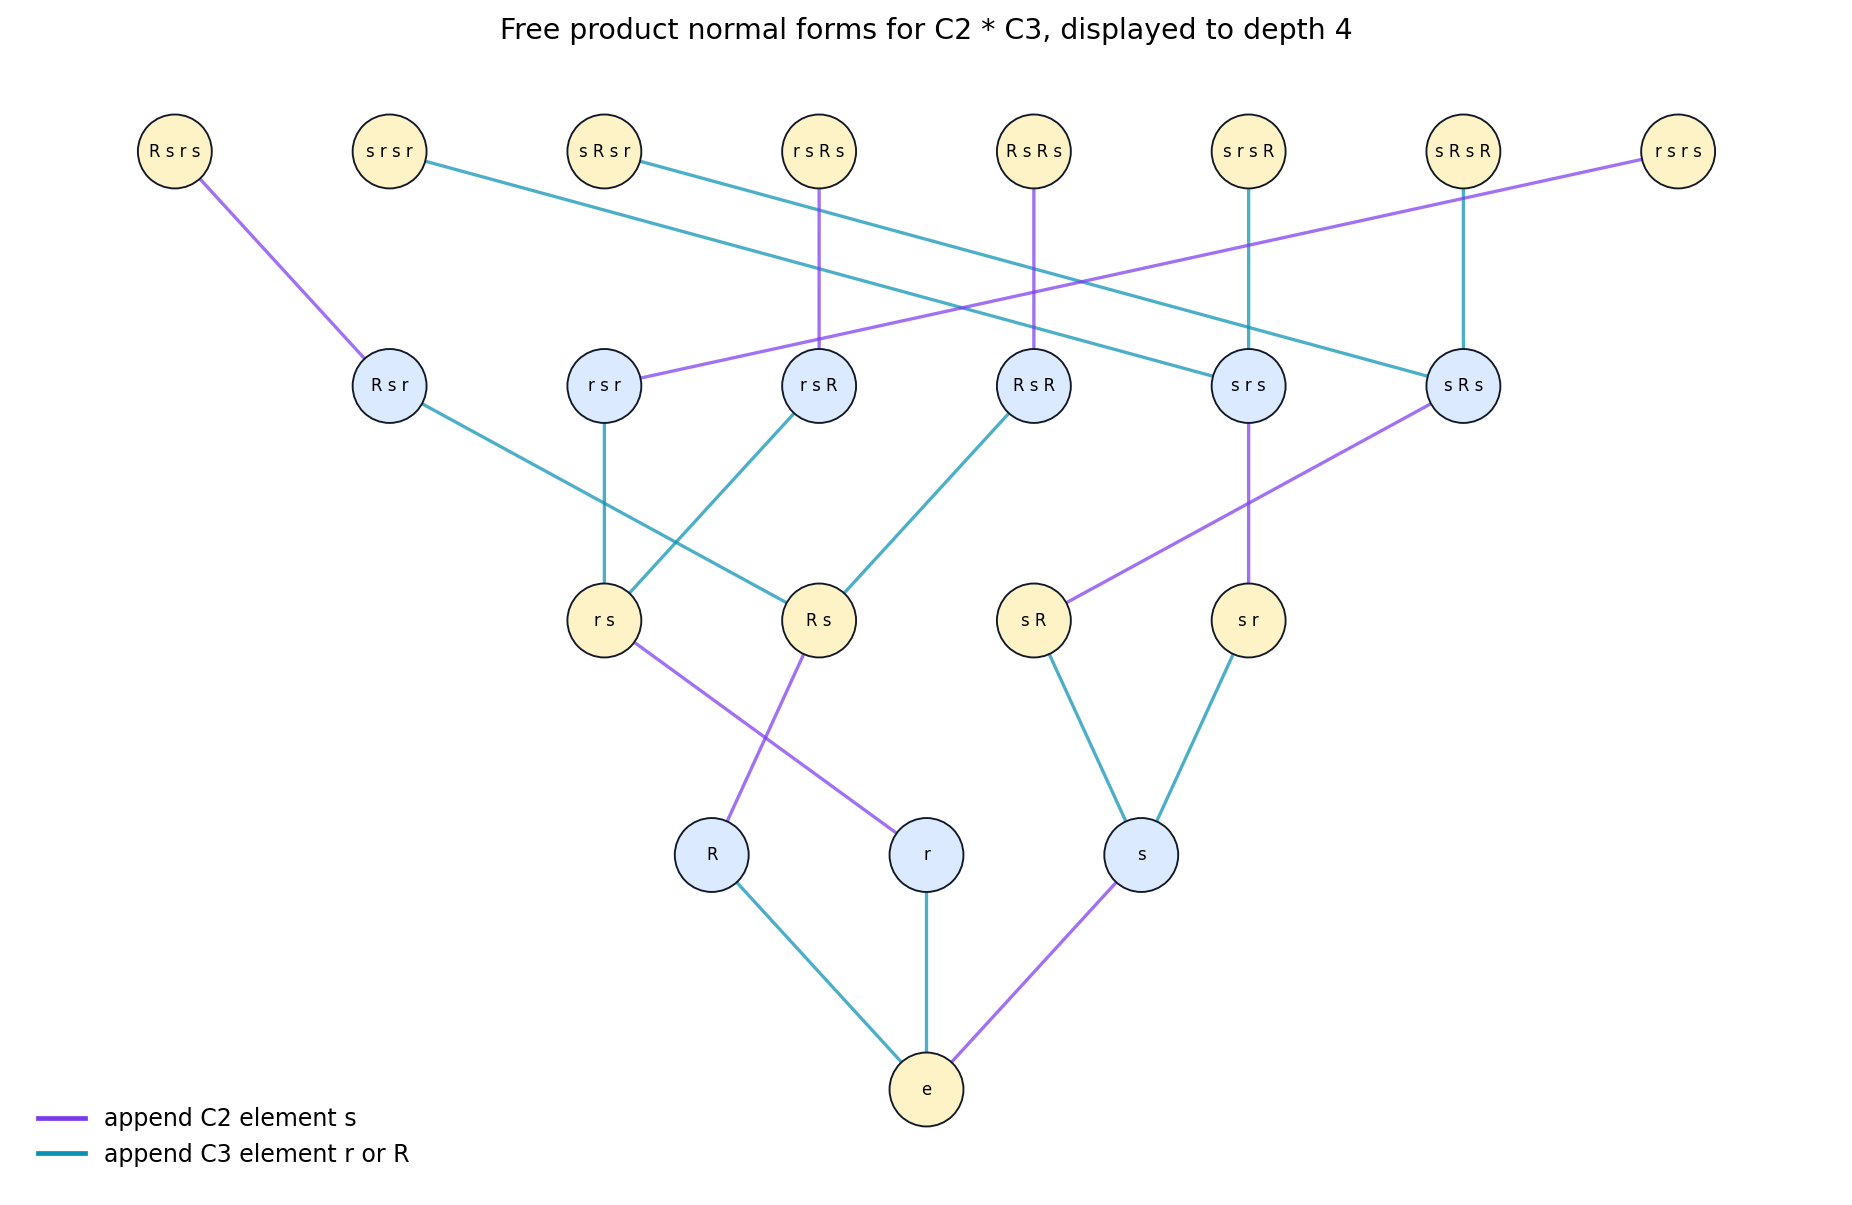

{'concept': 'free product normal forms',
 'model': 'C2 * C3 = <s,r | s^2, r^3>',
 'tree_depth': 4,
 'tree_nodes': 22,
 'tree_edges': 21,
 'tree_is_arborescence': True,
 'all_nodes_alternate_factors': True,
 'example_reductions_idempotent': True,
 'factor_relations_reduce_to_identity': True}

In [6]:
TOKEN_DATA = {"s": ("C2", 1, 2), "r": ("C3", 1, 3), "R": ("C3", 2, 3)}


def token_factor(token: str) -> str:
    return TOKEN_DATA[token][0]


def token_value(token: str) -> int:
    return TOKEN_DATA[token][1]


def token_from_factor_value(factor: str, value: int) -> str | None:
    if factor == "C2":
        return None if value % 2 == 0 else "s"
    if factor == "C3":
        value = value % 3
        if value == 0:
            return None
        return "r" if value == 1 else "R"
    raise ValueError(factor)


def free_product_reduce(tokens: list[str] | tuple[str, ...] | str) -> tuple[str, ...]:
    raw = [tok for tok in tokens.split() if tok] if isinstance(tokens, str) else list(tokens)
    stack: list[str] = []
    for tok in raw:
        if stack and token_factor(stack[-1]) == token_factor(tok):
            merged = token_from_factor_value(token_factor(tok), token_value(stack[-1]) + token_value(tok))
            if merged is None:
                stack.pop()
            else:
                stack[-1] = merged
        else:
            stack.append(tok)
    return tuple(stack)


def factors_alternate(tokens: tuple[str, ...]) -> bool:
    return all(token_factor(a) != token_factor(b) for a, b in zip(tokens, tokens[1:]))


def word_label(tokens: tuple[str, ...]) -> str:
    return "e" if not tokens else " ".join(tokens)


free_product_examples = [["s", "s", "r"], ["r", "r", "r", "s"], ["s", "r", "R", "s", "r"], ["r", "s", "r", "s", "R"]]
free_product_rows = []
for tokens in free_product_examples:
    reduced = free_product_reduce(tokens)
    free_product_rows.append({
        "raw_tokens": " ".join(tokens),
        "normal_form": word_label(reduced),
        "alternates_after_reduction": factors_alternate(reduced),
        "reduction_idempotent": free_product_reduce(reduced) == reduced,
    })
free_product_df = pd.DataFrame(free_product_rows)
free_product_csv = artifact_path(UNIT, "tables", "free-product-normal-form-examples.csv")
free_product_df.to_csv(free_product_csv, index=False)
artifact_manifest.append(free_product_csv)

FP = nx.DiGraph()
root = tuple()
FP.add_node(root, depth=0, label="e")
frontier = [root]
depth_limit = 4
for depth in range(depth_limit):
    next_frontier = []
    for word in frontier:
        last_factor = token_factor(word[-1]) if word else None
        for tok in ["s", "r", "R"]:
            if token_factor(tok) == last_factor:
                continue
            new_word = word + (tok,)
            FP.add_node(new_word, depth=len(new_word), label=word_label(new_word))
            FP.add_edge(word, new_word, token=tok)
            next_frontier.append(new_word)
    frontier = next_frontier

fp_pos = nx.multipartite_layout(FP, subset_key="depth", align="horizontal", scale=2.3)
fig, ax = plt.subplots(figsize=(11, 7.2))
edge_colors = ["#7c3aed" if FP.edges[e]["token"] == "s" else "#0891b2" for e in FP.edges]
nx.draw_networkx_edges(FP, fp_pos, ax=ax, edge_color=edge_colors, arrows=True, arrowstyle="-|>", arrowsize=12, width=1.4, alpha=0.72)
node_colors = ["#fef3c7" if len(node) % 2 == 0 else "#dbeafe" for node in FP.nodes]
nx.draw_networkx_nodes(FP, fp_pos, ax=ax, node_size=980, node_color=node_colors, edgecolors="#111827", linewidths=0.8)
nx.draw_networkx_labels(FP, fp_pos, labels={node: FP.nodes[node]["label"] for node in FP.nodes}, font_size=7, ax=ax)
ax.plot([], [], color="#7c3aed", linewidth=2, label="append C2 element s")
ax.plot([], [], color="#0891b2", linewidth=2, label="append C3 element r or R")
ax.set_title("Free product normal forms for C2 * C3, displayed to depth 4")
ax.axis("off")
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
free_product_png = save_matplotlib(fig, UNIT, "figures", "free-product-normal-form-tree.png", dpi=170)
plt.close(fig)
artifact_manifest.append(free_product_png)

free_product_checks = {
    "concept": "free product normal forms",
    "model": "C2 * C3 = <s,r | s^2, r^3>",
    "tree_depth": depth_limit,
    "tree_nodes": FP.number_of_nodes(),
    "tree_edges": FP.number_of_edges(),
    "tree_is_arborescence": nx.is_arborescence(FP),
    "all_nodes_alternate_factors": all(factors_alternate(node) for node in FP.nodes),
    "example_reductions_idempotent": bool(free_product_df["reduction_idempotent"].all()),
    "factor_relations_reduce_to_identity": free_product_reduce(["s", "s"]) == tuple() and free_product_reduce(["r", "r", "r"]) == tuple(),
}
free_product_check_path = save_json(free_product_checks, UNIT, "checks", "free-product-normal-form-checks.json")
check_manifest.append(free_product_check_path)

display(free_product_df)
display_artifact(free_product_png, width=950)
free_product_checks

## Applied Lab: What A Topological Presentation Gives You

Presentations from topology often come from loops around cells, edges, or knot arcs. Before trying to identify the whole group, one cheap invariant is the exponent-sum matrix of the relations. It records what survives after forcing all generators to commute, so it is a quick abelianized shadow of the presentation.

This lab compares a free group, a torus-style commutator presentation, the dihedral presentation above, and a braid-style two-generator relation used as a knot-group rehearsal. The commutator relation has zero exponent sum, which is why abelianization cannot distinguish `F(x,y)` from `Z x Z` even though the nonabelian presentations are different.

In [7]:
def exponent_sum_vector(word: str, generators: list[str]) -> list[int]:
    counts = {gen: 0 for gen in generators}
    for ch in clean_word(word):
        gen = ch.lower()
        if gen in counts:
            counts[gen] += 1 if ch.islower() else -1
    return [counts[gen] for gen in generators]


presentations = {
    "free_F2": {"generators": ["x", "y"], "relations": []},
    "commuting_torus_Z2": {"generators": ["x", "y"], "relations": ["xyXY"]},
    "dihedral_D10": {"generators": ["x", "y"], "relations": ["xxxxx", "yy", "xyxy"]},
    "trefoil_style_braid": {"generators": ["a", "b"], "relations": ["abaBAB"]},
}

lab_rows = []
for name, data in presentations.items():
    gens = data["generators"]
    rels = data["relations"]
    matrix = np.array([exponent_sum_vector(rel, gens) for rel in rels], dtype=int) if rels else np.zeros((0, len(gens)), dtype=int)
    rank = int(np.linalg.matrix_rank(matrix.astype(float))) if matrix.size else 0
    lab_rows.append({
        "presentation": name,
        "generators": ",".join(gens),
        "relations": ", ".join(rels) or "none",
        "exponent_sum_rows": matrix.tolist(),
        "abelianized_rank_lower_bound": len(gens) - rank,
        "relation_matrix_rank": rank,
    })
lab_df = pd.DataFrame(lab_rows)
lab_csv = artifact_path(UNIT, "tables", "presentation-abelianized-relation-matrices.csv")
lab_df.to_csv(lab_csv, index=False)
artifact_manifest.append(lab_csv)

lab_checks = {
    "concept": "presentation abelianized relation matrices",
    "presentations_checked": list(presentations),
    "commutator_has_zero_exponent_sum": exponent_sum_vector("xyXY", ["x", "y"]) == [0, 0],
    "dihedral_relation_matrix_rows": lab_df.loc[lab_df["presentation"] == "dihedral_D10", "exponent_sum_rows"].iloc[0],
    "trefoil_style_relation_has_balanced_total_exponent": sum(exponent_sum_vector("abaBAB", ["a", "b"])) == 0,
}
lab_check_path = save_json(lab_checks, UNIT, "checks", "presentation-lab-checks.json")
check_manifest.append(lab_check_path)

display(lab_df)
lab_checks

,presentation,generators,relations,exponent_sum_rows,abelianized_rank_lower_bound,relation_matrix_rank
0,free_F2,"x,y",none,[],2,0
1,commuting_torus_Z2,"x,y",xyXY,"[[0, 0]]",2,0
2,dihedral_D10,"x,y","xxxxx, yy, xyxy","[[5, 0], [0, 2], [2, 2]]",0,2
3,trefoil_style_braid,"a,b",abaBAB,"[[1, -1]]",1,1


{'concept': 'presentation abelianized relation matrices',
 'presentations_checked': ['free_F2',
  'commuting_torus_Z2',
  'dihedral_D10',
  'trefoil_style_braid'],
 'commutator_has_zero_exponent_sum': True,
 'dihedral_relation_matrix_rows': [[5, 0], [0, 2], [2, 2]],
 'trefoil_style_relation_has_balanced_total_exponent': True}

## Final Sanity Checks

The final cell checks the algebra and the artifact contract together. It verifies reduction idempotence, relation rewriting, presentation graph consistency, normal-closure loop closure, free-product alternation, and existence plus nonzero size for every generated artifact.

In [8]:
for path in artifact_manifest:
    min_bytes = 1024 if Path(path).suffix.lower() in {".png", ".html"} else 32
    assert_artifact(path, min_bytes=min_bytes)
for path in check_manifest:
    assert_artifact(path, min_bytes=64)

assert free_word_checks["reduction_idempotent"]
assert free_word_checks["inverse_product_reduces_to_identity"]
assert relation_rewriting_checks["all_relation_words_identity"]
assert relation_rewriting_checks["rewrite_examples_preserve_action"]
assert relation_rewriting_checks["rewrite_idempotent_on_examples"]
assert normal_closure_checks["conjugate_evaluates_to_identity"]
assert normal_closure_checks["relation_loop_closes_at_every_vertex"]
assert schreier_checks["all_presentation_relations_hold"]
assert free_product_checks["tree_is_arborescence"]
assert free_product_checks["all_nodes_alternate_factors"]
assert free_product_checks["factor_relations_reduce_to_identity"]
assert lab_checks["commutator_has_zero_exponent_sum"]

outgoing_by_generator = {
    d_label(state): {gen: sum(1 for _, _, data in G.out_edges(state, data=True) if data["generator"] == gen) for gen in ("x", "y")}
    for state in elements
}
regular_outgoing_by_generator = all(counts == {"x": 1, "y": 1} for counts in outgoing_by_generator.values())
relation_loops_close_everywhere = all(path_for_word(word, start=state)[-1] == state for state in elements for word in relation_words.values())
strongly_connected = nx.is_strongly_connected(nx.DiGraph(G))
assert regular_outgoing_by_generator
assert relation_loops_close_everywhere
assert strongly_connected

final_check_path = artifact_path(UNIT, "checks", "appendix-final-sanity-checks.json")
all_check_paths = [*check_manifest, final_check_path]
final_checks = {
    "unit": UNIT,
    "source_span": "Armstrong Basic Topology appendix, printed pp. 241-243; PDF reader pp. 248-250",
    "artifacts_checked": [book_rel(path) for path in artifact_manifest],
    "check_files": [book_rel(path) for path in all_check_paths],
    "artifact_count": len(artifact_manifest),
    "check_file_count": len(all_check_paths),
    "free_reduction_idempotent": free_word_checks["reduction_idempotent"],
    "relation_rewriting_valid": relation_rewriting_checks["rewrite_examples_preserve_action"],
    "cayley_regular_outgoing_by_generator": regular_outgoing_by_generator,
    "cayley_relation_loops_close_everywhere": relation_loops_close_everywhere,
    "cayley_strongly_connected": strongly_connected,
    "schreier_relations_hold": schreier_checks["all_presentation_relations_hold"],
    "normal_closure_conjugate_identity": normal_closure_checks["conjugate_evaluates_to_identity"],
    "free_product_tree_alternates": free_product_checks["all_nodes_alternate_factors"],
}
save_json(final_checks, UNIT, "checks", "appendix-final-sanity-checks.json")
assert_artifact(final_check_path, min_bytes=128)
check_manifest.append(final_check_path)

pd.DataFrame([{ "check": key, "value": value } for key, value in final_checks.items() if not isinstance(value, list)])

,check,value
0,unit,appendix-generators-and-relations
1,source_span,"Armstrong Basic Topology appendix, printed pp...."
2,artifact_count,10
3,check_file_count,7
4,free_reduction_idempotent,True
5,relation_rewriting_valid,True
6,cayley_regular_outgoing_by_generator,True
7,cayley_relation_loops_close_everywhere,True
8,cayley_strongly_connected,True
9,schreier_relations_hold,True


## Takeaways

- A free group is best treated as a normal-form machine: only inverse cancellation is available.
- A presentation is a quotient recipe: relation words and all their conjugates become identity words.
- Cayley and Schreier-style graphs make relations inspectable as closed paths.
- Free products preserve the internal relations of the factors and add no cross-factor relations, so alternating normal forms are the main invariant to watch.
- For topology, this appendix supplies the algebraic interface between geometric loops and computable group data.